# Build Sol Dataset

## Install necessary libraries from python

In [1]:
%%capture
# Use Gpu
!pip install dgl==2.0.0 -f https://data.dgl.ai/wheels/cu121/repo.html
# Only use cpu
# !pip install dgl==1.1.2

In [2]:
%%capture
# !apt install libgraphviz-dev
# !pip install pygraphviz
!pip install networkx
!pip install slither-analyzer

## Import Python libraries

In [3]:
from concurrent.futures import ThreadPoolExecutor
from random import sample
import json
import multiprocessing
import traceback
import pandas as pd
import os
from pathlib import Path
import networkx as nx
# import pygraphviz as pgv
import matplotlib.pyplot as plt
import nltk
import dgl
import os
import shutil
import random
from slither.slither import Slither
from typing import Tuple, Optional, Dict
from copy import deepcopy
from pathlib import Path
import glob
from multiprocessing import Pool as ThreadPool
from functools import partial
import torch.nn as nn
import torch
from torch import Tensor
import torch.nn.functional as F
from dgl.nn import GraphConv, GATConv, TAGConv, SAGEConv, GINConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from dgl.nn.pytorch import Sequential
import pickle
import random
import numpy as np
from tqdm import tqdm
from dgl.data import DGLDataset
from dgl.dataloading import GraphDataLoader
os.environ["TORCH_DYNAMO_DISABLE"] = "1"

def seed_everything(seed: int):
    # Hàm đặt seed cố định cho tất cả các thư viện để kết quả có thể tái tạo lại được
    import random, os
    import numpy as np
    import torch
    
    random.seed(seed)  # Cố định seed cho thư viện random
    # os.environ['PYTHONHASHSEED'] = str(seed)  # Cố định hash seed của Python
    np.random.seed(seed)  # Cố định seed cho NumPy
    torch.manual_seed(seed)  # Cố định seed cho PyTorch CPU
    torch.cuda.manual_seed(seed)  # Cố định seed cho PyTorch GPU
    torch.backends.cudnn.deterministic = True  # Đảm bảo tính nhất quán của thuật toán cuDNN
    torch.backends.cudnn.benchmark = True  # Tối ưu hóa tốc độ tính toán

seed_everything(42)

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


# Functions

In [4]:
def plot(x: list, y: list):
    x = np.array(x)
    y = np.array(y)

    plt.plot(x, y)
    plt.title("Decrease of loss over epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

In [5]:
def readData(path: str, n_scam: int):
    dic = {
        "filename": [],
    }
    cnt0, cnt1 = 0, 0
    for label in ["Vulnerable_Fcg"]:
        for file in sorted(os.listdir(path + "/" + label)):
            if file.endswith(".fcg"):
                if cnt1 < n_scam:
                    dic['filename'].append("/".join([path, label, file]))
                    cnt1 += 1
    df = pd.DataFrame(dic)
    return df

In [33]:
import json

def loadfeatureGraph(path):
    """
    path: path to fcg file
    return: dgl.DGLGraph
    """
    g = dgl.load_graphs(path)[0][0]

    # -------------------------------------------
    file_path_split = path.split("/")
    info_path = "/".join(file_path_split[:-1]) + "/" + file_path_split[-1].replace(".fcg", "_mapping.json")
    info_data = json.load(open(info_path, "r"))
    cnt = 0
    for name, reason in info_data['reason'].items():
        if "No reason provided" not in reason:
            cnt += 1

    cp = False
    for label in g.ndata['node_label'].tolist():
        if label == 1:
            cp = True
            break

    fail = 0
    if cnt == 1 and cp != True:
        fail = 1
    elif cnt > 1 and cp != True:
        fail = 2

    if cnt == 1:
        new_node_label = []
        for name, reason in info_data['reason'].items():
            if "No reason provided" not in reason:
                new_node_label.append(1)
            else:
                new_node_label.append(0)
    
        g.ndata['node_label'] = torch.tensor(new_node_label)
    # -------------------------------------------
    
    # Assuming features are named 'features' and node labels 'node_labels'
    # If feature names are different (e.g., 'featuresH'), adjust here.
    # g.ndata["features"] = g.ndata["featuresH"] 
    return g, fail, cnt


def createBatchMulThread(data, max_works):
    """
    data: Graph paths,
    max_works: number of thread use
    return list[DGLGraph]
    """
    pathfiles = data
    with ThreadPoolExecutor(max_works) as executor:
        graphs = list(tqdm(executor.map(loadfeatureGraph, pathfiles), total=len(pathfiles), desc="Loading graphs"))

    goodgraphs = []
    cnt_fail_1, cnt_fail_more1 = 0, 0
    cnt_1, cnt_more1 = 0, 0
    for g, fail, cunt in graphs:
        cnt = 0
        if fail == 1: cnt_fail_1 += 1
        if fail == 2: cnt_fail_more1 += 1
        if cunt == 1: cnt_1 += 1
        if cunt > 1: cnt_more1 += 1            
        for label in g.ndata['node_label'].tolist():
            if label == 1:
                cnt += 1
        num_classes = len(torch.unique(g.ndata['node_label']))
        if cnt >= 1:
            goodgraphs.append(g)

    print(f"Number of 1 syntax SC Agent has failed: {cnt_fail_1} / {cnt_1} total number of files with 1 syntax")
    print(f"Number of more than 1 syntax SC Agent has failed: {cnt_fail_more1} / {cnt_more1} total number of files with more than 1 syntax")
    print(f"Total SC Agent has failed: {cnt_fail_1 + cnt_fail_more1} / {len(graphs)}")
    print(f"Even though the Agent classify wrong for {cnt_fail_1} of 1 syntax vulnerable source code, but these source code are still vulnerable so we decide to keep these source code and change their label as vulnerable for the only node contain syntax.")
    return goodgraphs

In [ ]:
# g = loadfeatureGraph("/kaggle/input/ngclassificationtime/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Test/Vulnerable_Fcg/0x051fda7486480dd5abcf5dd742ef002a2ebb9ea0.fcg")
# print(g.ndata['node_label'].tolist())

# file_path_split = "/kaggle/input/ngclassificationtime/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Test/Vulnerable_Fcg/0x051fda7486480dd5abcf5dd742ef002a2ebb9ea0.fcg".split("/")
# print(file_path_split)
# info_path = "/".join(file_path_split[:-1]) + "/" + file_path_split[-1].replace(".fcg", "_mapping.json")
# print(info_path)
# info_data = json.load(open(info_path, "r"))

# new_node_label = []
# for name, reason in info_data['reason'].items():
#     if "Not vulnerable:" not in reason and "No reason provided" not in reason:
#         new_node_label.append(1)
#     else:
#         new_node_label.append(0)

# print(new_node_label)

# g.ndata['node_label'] = torch.tensor(new_node_label)

# print(g.ndata['node_label'])

# Model GNNs

In [34]:
def get_convolution_layer(
        input_dimension: int,
        output_dimension: int,
        name: list,
        agg_hidden_dimension: int = 1024, # Only use for GINConv
        heads: int = 0 # Only use for GATConv
) -> Optional[nn.Module]:
    mlp, gin_agg, sage_agg = None, 'sum', 'mean'
    if name[0] == "GIN":
        mlp = nn.Sequential()
        mlp.append(nn.Linear(input_dimension, agg_hidden_dimension))
        mlp.append(nn.ReLU())
        mlp.append(nn.Linear(agg_hidden_dimension, output_dimension))
        gin_agg = name[1]

    if name[0] == "SAGE":
        sage_agg = name[1]

    return {"GCN": GraphConv(input_dimension, output_dimension, activation=F.relu),
            "SAGE": SAGEConv(input_dimension, output_dimension, activation=F.relu, norm=F.normalize, aggregator_type=sage_agg),
            "GAT": GATConv(input_dimension, output_dimension, num_heads=heads, activation=F.relu, feat_drop=0.0, attn_drop=0.0),
            "TAG": TAGConv(input_dimension, output_dimension, k=4, activation=F.relu),
            "GIN": GINConv(apply_func=mlp, activation=F.relu, aggregator_type=gin_agg)
            }.get(name[0], None)

class NodeClassifierGNN(nn.Module):
    def __init__(self, mtype, infeats, hfeats: list, fc1_layer, fc2_layer, outclass, ginfeat=None):
        super(NodeClassifierGNN, self).__init__()
        self.mtype = mtype
        self.hfeats = hfeats
        self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

        # Define convolutional layers
        self.conv_layers = nn.ModuleList()
        current_dim = infeats
        
        for i, hdim in enumerate(hfeats):
            if mtype[0] == "GAT":
                # For GAT, the output dimension is hdim * num_heads
                num_heads = 8 if i < len(hfeats) -1 else 1 # Last layer with 1 head
                conv = get_convolution_layer(current_dim, hdim, name=mtype, heads=num_heads)
                current_dim = hdim * num_heads
            else:
                conv = get_convolution_layer(current_dim, hdim, name=mtype, agg_hidden_dimension=ginfeat if mtype[0] == "GIN" else None)
                current_dim = hdim
            self.conv_layers.append(conv)
            
        # Classifier layers
        self.fc1 = nn.Linear(current_dim, fc1_layer)
        self.fc2 = nn.Linear(fc1_layer, fc2_layer)
        self.fc3 = nn.Linear(fc2_layer, outclass)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, g, infeats):
        h = infeats
        for i, layer in enumerate(self.conv_layers):
            h = layer(g, h)
            if self.mtype[0] == "GAT":
                # Reshape from [num_nodes, num_heads, out_dim] to [num_nodes, num_heads * out_dim]
                h = h.reshape(h.shape[0], -1)
        
        # Node-level features are now ready for classification
        # No pooling is applied
        
        ans = self.fc1(h)
        ans = F.relu(ans)
        ans = self.fc2(ans)
        ans = F.relu(ans)
        return self.fc3(ans)

    def save(self, path):
        torch.save(self.state_dict(), path)

    def load(self, path):
        self.load_state_dict(torch.load(path))

# Training

In [8]:
class GraphDataset(DGLDataset):
    def __init__(self, graphs):
        super().__init__(name='graph_dataset')
        self.graphs = graphs

    def __getitem__(self, idx):
        # Return the graph itself. The labels are part of the graph object.
        return self.graphs[idx]

    def __len__(self):
        return len(self.graphs)

In [30]:
# Add this import at the top
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix


def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_and_eval(dataloader, tdataloader, mtype, s_epoch, e_epoch, n_feats, hfeats, outclass, ginfeat):
    seed_everything(42)
    # Use the new NodeClassifierGNN model
    model = NodeClassifierGNN(mtype=mtype, infeats=n_feats, hfeats=hfeats, fc1_layer=256, fc2_layer=64, outclass=outclass, ginfeat=ginfeat)
    model.to(model.device)
    print(model)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    result = {
        "loss": [],
        "val_acc": [],
        "val_f1": [],
        "epoch": []
    }

    for epoch in tqdm(range(s_epoch, e_epoch), desc="Training Epochs"):
        model.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        for batched_graph in dataloader:
            batched_graph = batched_graph.to(model.device)
            feats = batched_graph.ndata['featuresH'].float()
            # Get node labels from the graph
            labels = batched_graph.ndata['node_label'].long()
            
            pred = model(batched_graph, feats)
            loss = criterion(pred, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            preds_batch = pred.argmax(dim=1)
            all_preds.extend(preds_batch.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        epoch_loss = total_loss / len(dataloader)
        epoch_acc = accuracy_score(all_labels, all_preds)
        result['loss'].append(epoch_loss)
        result['epoch'].append(epoch)
        # print(f"Epoch: {epoch} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc*100:.4f}%")
        
        # Evaluation
        model.eval()
        with torch.no_grad():
            tpred, tlabel = [], []
            for tbatched_graph in tdataloader:
                tbatched_graph = tbatched_graph.to(model.device)
                tfeats = tbatched_graph.ndata['featuresH'].float()
                tlabels = tbatched_graph.ndata['node_label'].long()
                
                out = model(tbatched_graph, tfeats)
                preds = out.argmax(dim=1)
                
                tpred.extend(preds.cpu().numpy())
                tlabel.extend(tlabels.cpu().numpy())

            if epoch == 49:
                print("\n" + "="*50)
                print("                Validation Results")
                print("="*50)
    
                # Generate and print the classification report
                # This is the most important output for an imbalanced dataset!
                report = classification_report(tlabel, tpred, target_names=['Class 0 (Non-Vul)', 'Class 1 (Vul)'])
                print(report)
                
                # For a better visual, display the confusion matrix
                cm = confusion_matrix(tlabel, tpred)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Vul', 'Vul'])
                disp.plot(cmap=plt.cm.Blues)
                plt.title("Confusion Matrix")
                plt.show()
            
            val_acc = accuracy_score(tlabel, tpred)
            val_f1 = f1_score(tlabel, tpred, average='weighted')
            val_precision = precision_score(tlabel, tpred, average='weighted')
            val_recall = recall_score(tlabel, tpred, average='weighted')
            
            result['val_acc'].append(val_acc)
            result['val_f1'].append(val_f1)
            
            # print(f'Val Accuracy: {val_acc * 100:.2f}%')
            # print(f'Val F1 Score: {val_f1 * 100:.2f}%')
            # print(f'Val Precision: {val_precision * 100:.2f}%')
            # print(f'Val Recall: {val_recall * 100:.2f}%')

    print("\n--- Plotting Results ---")
    print("Loss vs. Epochs")
    plot(result["epoch"], result["loss"])
    print("Validation Accuracy vs. Epochs")
    plot(result["epoch"], result["val_acc"])
    print("Validation F1-Score vs. Epochs")
    plot(result["epoch"], result["val_f1"])
    
    return result

Loading graphs: 100%|██████████| 281/281 [00:00<00:00, 523.74it/s]


Number of 1 syntax SC Agent has failed: 43 / 208 total number of files with 1 syntax
Number of more than 1 syntax SC Agent has failed: 6 / 73 total number of files with more than 1 syntax
Total SC Agent has failed: 49 / 281
Even though the Agent classify wrong for 43 of 1 syntax vulnerable source code, but these source code are still vulnerable so we decide to keep these source code and change their label as vulnerable for the only node contain syntax.
Train Graph Count: 275


Loading graphs: 100%|██████████| 71/71 [00:00<00:00, 545.88it/s]


Number of 1 syntax SC Agent has failed: 11 / 57 total number of files with 1 syntax
Number of more than 1 syntax SC Agent has failed: 1 / 14 total number of files with more than 1 syntax
Total SC Agent has failed: 12 / 71
Even though the Agent classify wrong for 11 of 1 syntax vulnerable source code, but these source code are still vulnerable so we decide to keep these source code and change their label as vulnerable for the only node contain syntax.
Test Graph Count: 70
Detected 2 classes for node classification.
NodeClassifierGNN(
  (conv_layers): ModuleList(
    (0): GATConv(
      (fc): Linear(in_features=768, out_features=2048, bias=False)
      (feat_drop): Dropout(p=0.0, inplace=False)
      (attn_drop): Dropout(p=0.0, inplace=False)
      (leaky_relu): LeakyReLU(negative_slope=0.2)
    )
    (1): GATConv(
      (fc): Linear(in_features=2048, out_features=128, bias=False)
      (feat_drop): Dropout(p=0.0, inplace=False)
      (attn_drop): Dropout(p=0.0, inplace=False)
      (lea

Training Epochs:  98%|█████████▊| 49/50 [00:07<00:00,  6.77it/s]


                Validation Results
                   precision    recall  f1-score   support

Class 0 (Non-Vul)       1.00      1.00      1.00      2642
    Class 1 (Vul)       0.95      0.92      0.94        78

         accuracy                           1.00      2720
        macro avg       0.97      0.96      0.97      2720
     weighted avg       1.00      1.00      1.00      2720



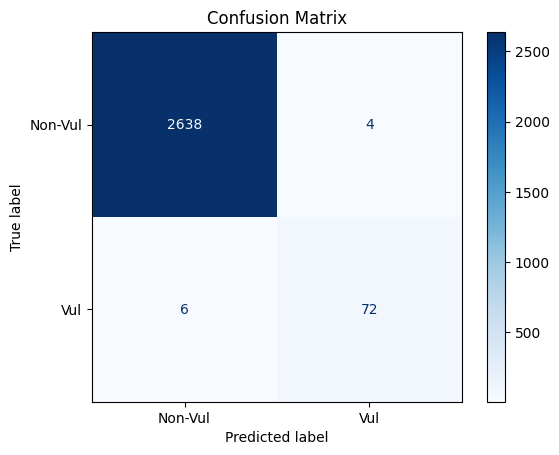

Training Epochs: 100%|██████████| 50/50 [00:07<00:00,  6.47it/s]



--- Plotting Results ---
Loss vs. Epochs


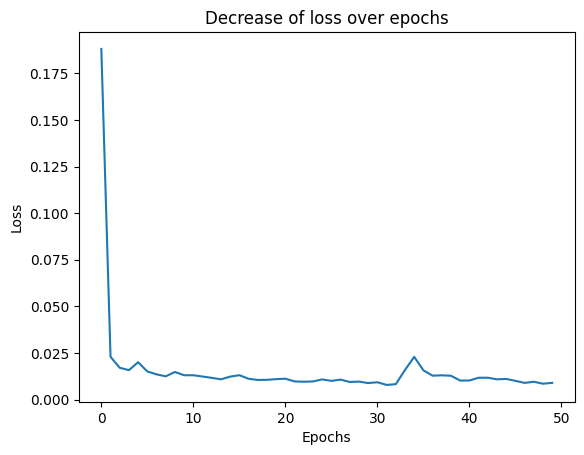

Validation Accuracy vs. Epochs


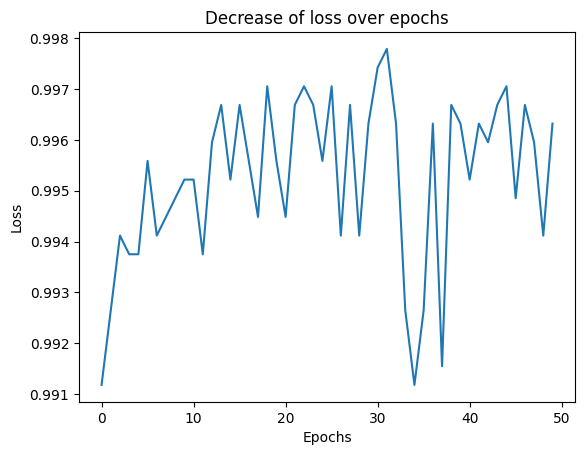

Validation F1-Score vs. Epochs


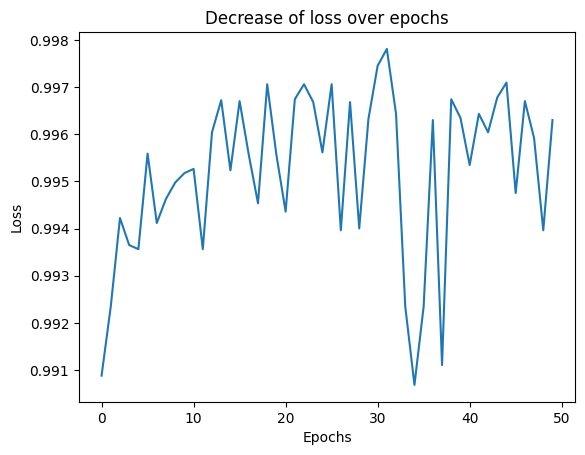

In [35]:
# --- Main Execution ---

# For demonstration, let's assume `g.ndata["node_labels"]` exists and has `num_classes` unique values.
# You need to ensure your graph creation process correctly adds these labels.
# For example:
# g = dgl.graph(...)
# g.ndata['features'] = torch.randn(g.num_nodes(), 773)
# g.ndata['node_labels'] = torch.randint(0, num_classes, (g.num_nodes(),))
# dgl.save_graphs("path/to/graph.fcg", [g])

# NOTE: The original `readData` function might not be fully representative of a node classification task,
# as it assigns a single label per graph. The core logic change assumes node labels are loaded with the graph.

data_path = "/kaggle/input/ngclassificationdataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset"

# This part might need adjustment based on how you structure your train/test split for node classification.
# Often for node classification, you work with a single large graph and use node masks for train/val/test splits.
# However, if you have many small graphs, this approach is fine.
train_df = readData(f"{data_path}/Train", 1000) # Using a smaller number for faster demo
test_df = readData(f"{data_path}/Test", 600)


# Load graphs
# Ensure your loaded graphs have g.ndata["node_labels"]
graphs = createBatchMulThread(train_df['filename'].tolist(), 16)
print(f"Train Graph Count: {len(graphs)}")
graphs = [dgl.add_self_loop(g) for g in graphs]
dataset = GraphDataset(graphs)
dataloader = GraphDataLoader(dataset, batch_size=32, drop_last=False, shuffle=True)

tgraphs = createBatchMulThread(test_df['filename'].tolist(), 16)
print(f"Test Graph Count: {len(tgraphs)}")
tgraphs = [dgl.add_self_loop(g) for g in tgraphs]
tdataset = GraphDataset(tgraphs)
tdataloader = GraphDataLoader(tdataset, batch_size=128, drop_last=False, shuffle=False)

# Parameters
n_feats = graphs[0].ndata['featuresH'].shape[1]
# Determine the number of classes from the node labels in your data
# This is a placeholder; you must set this value based on your dataset
try:
    # Check the number of unique labels in the first graph's node_labels
    num_classes = len(torch.unique(graphs[0].ndata['node_label']))
    print(f"Detected {num_classes} classes for node classification.")
except KeyError:
    print("Error: `g.ndata['node_label']` not found in the graph.")
    print("Please ensure your graphs are saved with node-level labels.")
    num_classes = 2 # Defaulting to 2 for now
    

# Run training and evaluation
result = train_and_eval(
    dataloader=dataloader, 
    tdataloader=tdataloader, 
    mtype=['GAT', ''], # Example: Using GAT
    s_epoch=0, 
    e_epoch=50, # Reduced epochs for demo
    n_feats=n_feats,
    hfeats=[256, 128], # Hidden layer dimensions
    outclass=num_classes, # Number of node classes
    ginfeat=1024
)

Loading graphs: 100%|██████████| 190/190 [00:00<00:00, 563.36it/s]


Number of 1 syntax SC Agent has failed: 60 / 107 total number of files with 1 syntax
Number of more than 1 syntax SC Agent has failed: 19 / 82 total number of files with more than 1 syntax
Total SC Agent has failed: 79 / 190
Train Graph Count: 170


Loading graphs: 100%|██████████| 96/96 [00:00<00:00, 561.88it/s]


Number of 1 syntax SC Agent has failed: 28 / 48 total number of files with 1 syntax
Number of more than 1 syntax SC Agent has failed: 8 / 48 total number of files with more than 1 syntax
Total SC Agent has failed: 36 / 96
Test Graph Count: 88
Detected 2 classes for node classification.


/usr/local/lib/python3.10/dist-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


NodeClassifierGNN(
  (conv_layers): ModuleList(
    (0): GraphConv(in=768, out=2048, normalization=both, activation=<function relu at 0x78a8685aacb0>)
    (1): GraphConv(in=2048, out=2048, normalization=both, activation=<function relu at 0x78a8685aacb0>)
  )
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


Training Epochs:   0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Training Epochs:   4%|▍         | 2/50 [00:00<00:07,  6.45it/s]/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Training Epochs:   6%|▌         | 3/50 [00:00<00:06,  6.95it/s]/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to 


                Validation Results
                   precision    recall  f1-score   support

Class 0 (Non-Vul)       0.99      0.97      0.98      2971
    Class 1 (Vul)       0.56      0.81      0.66       141

         accuracy                           0.96      3112
        macro avg       0.78      0.89      0.82      3112
     weighted avg       0.97      0.96      0.97      3112



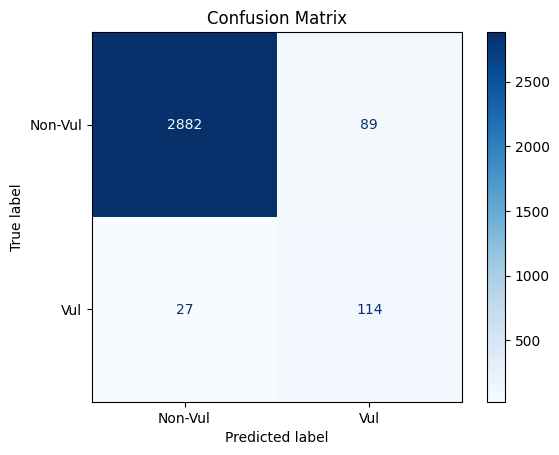

Training Epochs: 100%|██████████| 50/50 [00:06<00:00,  7.89it/s]



--- Plotting Results ---
Loss vs. Epochs


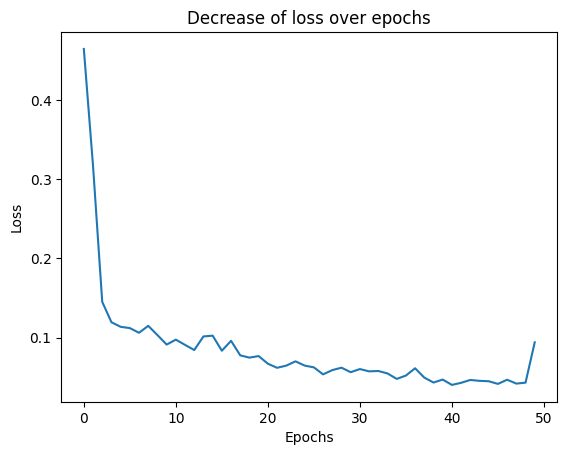

Validation Accuracy vs. Epochs


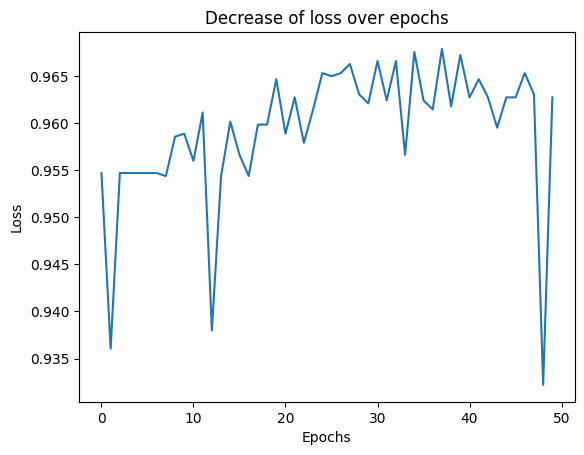

Validation F1-Score vs. Epochs


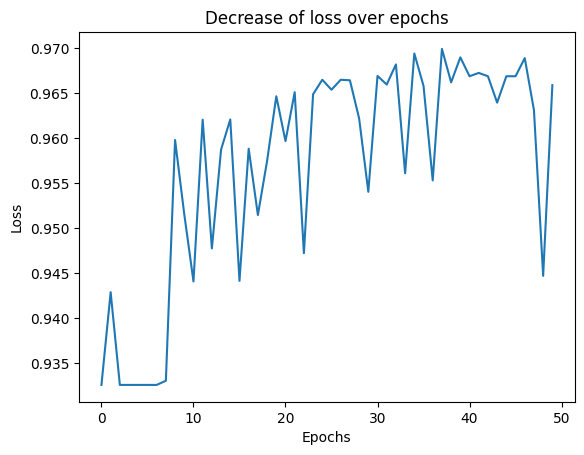

In [32]:
# --- Main Execution ---

# For demonstration, let's assume `g.ndata["node_labels"]` exists and has `num_classes` unique values.
# You need to ensure your graph creation process correctly adds these labels.
# For example:
# g = dgl.graph(...)
# g.ndata['features'] = torch.randn(g.num_nodes(), 773)
# g.ndata['node_labels'] = torch.randint(0, num_classes, (g.num_nodes(),))
# dgl.save_graphs("path/to/graph.fcg", [g])

# NOTE: The original `readData` function might not be fully representative of a node classification task,
# as it assigns a single label per graph. The core logic change assumes node labels are loaded with the graph.

data_path = "/kaggle/input/ngclassificationtime/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset"

# This part might need adjustment based on how you structure your train/test split for node classification.
# Often for node classification, you work with a single large graph and use node masks for train/val/test splits.
# However, if you have many small graphs, this approach is fine.
train_df = readData(f"{data_path}/Train", 1000) # Using a smaller number for faster demo
test_df = readData(f"{data_path}/Test", 600)





# Load graphs
# Ensure your loaded graphs have g.ndata["node_labels"]
graphs = createBatchMulThread(train_df['filename'].tolist(), 16)
print(f"Train Graph Count: {len(graphs)}")
graphs = [dgl.add_self_loop(g) for g in graphs]
dataset = GraphDataset(graphs)
dataloader = GraphDataLoader(dataset, batch_size=32, drop_last=False, shuffle=True)

tgraphs = createBatchMulThread(test_df['filename'].tolist(), 16)
print(f"Test Graph Count: {len(tgraphs)}")
tgraphs = [dgl.add_self_loop(g) for g in tgraphs]
tdataset = GraphDataset(tgraphs)
tdataloader = GraphDataLoader(tdataset, batch_size=128, drop_last=False, shuffle=False)

# Parameters
n_feats = graphs[0].ndata['featuresH'].shape[1]
# Determine the number of classes from the node labels in your data
# This is a placeholder; you must set this value based on your dataset
try:
    # Check the number of unique labels in the first graph's node_labels
    num_classes = len(torch.unique(graphs[0].ndata['node_label']))
    print(f"Detected {num_classes} classes for node classification.")
except KeyError:
    print("Error: `g.ndata['node_label']` not found in the graph.")
    print("Please ensure your graphs are saved with node-level labels.")
num_classes = 2 # Defaulting to 2 for now
    

# Run training and evaluation
result = train_and_eval(
    dataloader=dataloader, 
    tdataloader=tdataloader, 
    mtype=['GCN', ''], # Example: Using GAT
    s_epoch=0, 
    e_epoch=50, # Reduced epochs for demo
    n_feats=n_feats,
    hfeats=[2048, 2048], # Hidden layer dimensions
    outclass=num_classes, # Number of node classes
    ginfeat=1024
)

In [26]:
!pip install --upgrade torch torchvision

   25l   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/821.2 MB ? eta -:--:--━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.9/821.2 MB 28.4 MB/s eta 0:00:29━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/821.2 MB 53.9 MB/s eta 0:00:16━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/821.2 MB 73.1 MB/s eta 0:00:12╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/821.2 MB 110.0 MB/s eta 0:00:08╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/821.2 MB 138.5 MB/s eta 0:00:06━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.5/821.2 MB 148.4 MB/s eta 0:00:06━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/821.2 MB 153.8 MB/s eta 0:00:06━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.6/821.2 MB 163.2 MB/s eta 0:00:05━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/821.2 MB 164.5 MB/s eta 0:00:05━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/821.2 MB 168.7 MB/s eta 0:00:05━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/821.2 MB 161.3 MB/s eta 0:00:05━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/821.2 MB 161.8 MB/s eta 0:00:05━━━╺━━